In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('/Superstore_Data.csv', encoding='latin1')

print(df.shape)
print(df.dtypes)
df.head()

df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df.isnull().sum())

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


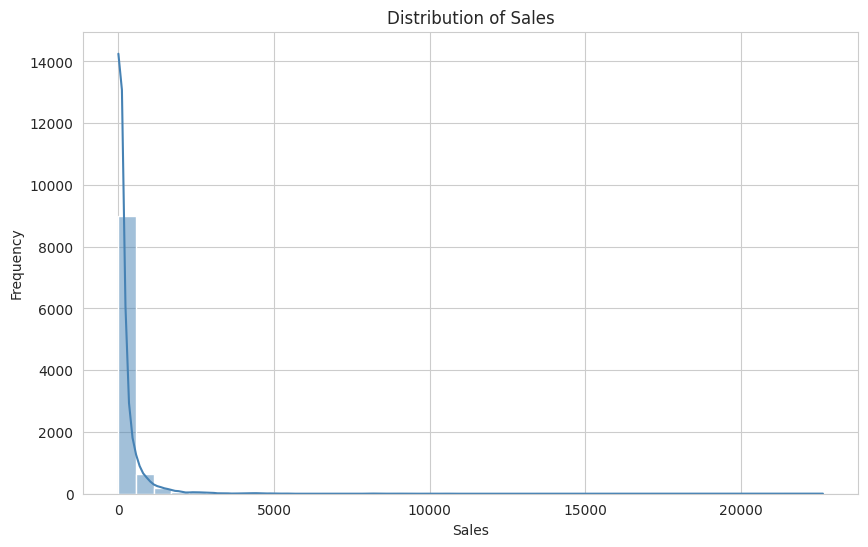

Skewness: 12.97
Mean: 229.86, Median: 54.49


In [ ]:
# ===== Task 1: Univariate Analysis of Sales =====

plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

skewness = df['Sales'].skew()
mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()

print(f"Skewness: {skewness:.2f}")
print(f"Mean: {mean_sales:.2f}, Median: {median_sales:.2f}")

The skewness value is positive and the mean is noticeably higher than the median, indicating a right-skewed distribution (a long tail of a few high-value sales pulling the average up). This means the mean is not a reliable summary here — the median better represents a "typical" sale

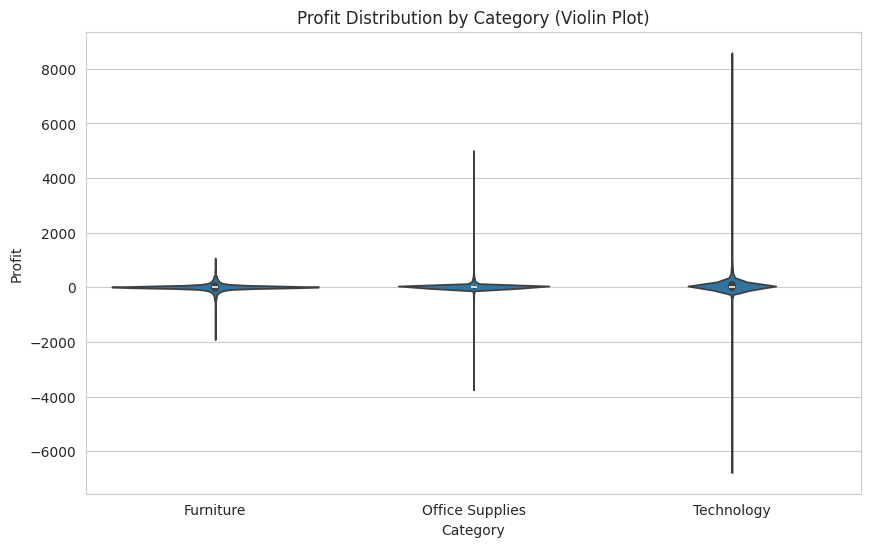

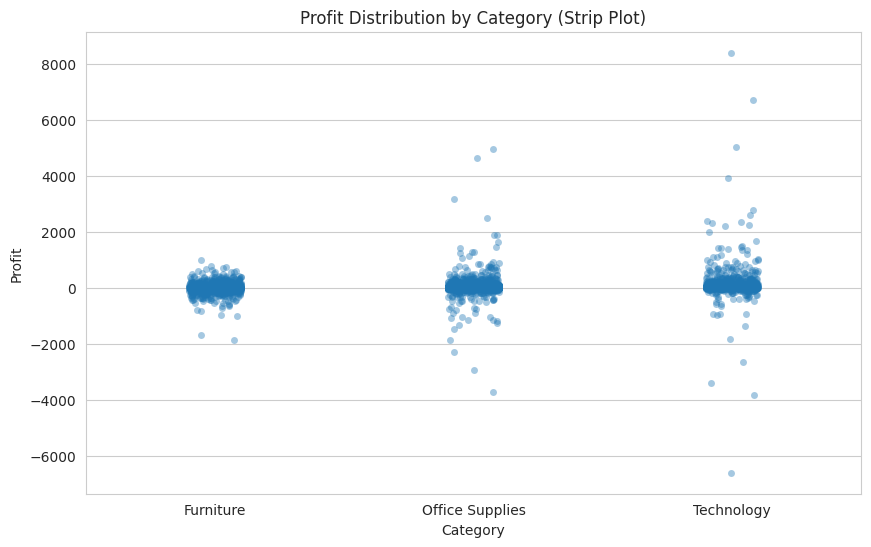

In [ ]:
# ===== Task 2: Profit by Category - Violin vs Strip =====

plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category (Violin Plot)')
plt.show()

plt.figure(figsize=(10,6))
sns.stripplot(data=df, x='Category', y='Profit', jitter=True, alpha=0.4)
plt.title('Profit Distribution by Category (Strip Plot)')
plt.show()

The violin plot better reveals a category with a bimodal or unusually spread-out profit distribution, since it shows the shape/density of the data directly (widening at areas with more points), whereas the strip plot only shows individual points which get hard to interpret as a shape when there are many overlapping values.

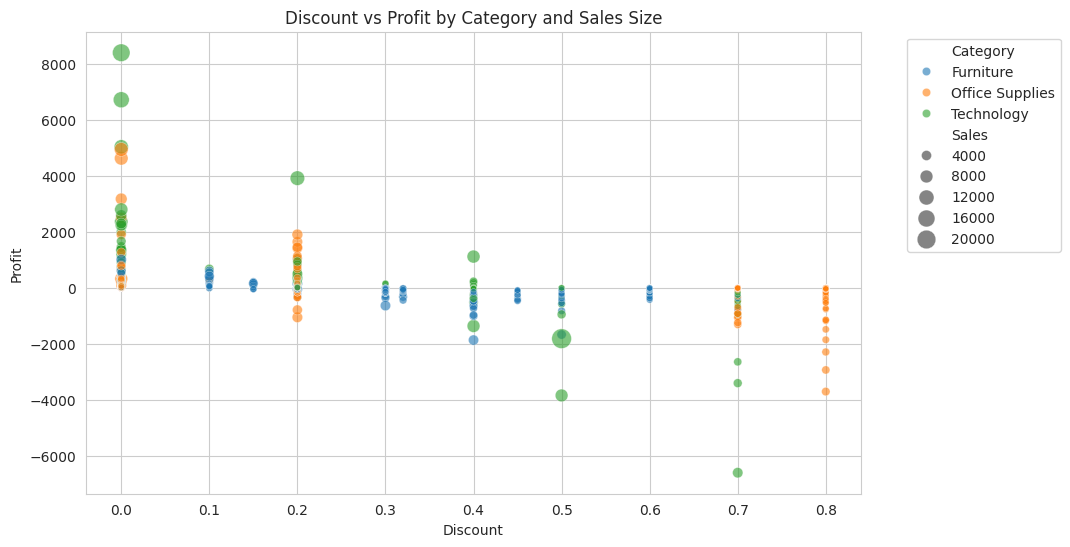

In [ ]:
# ===== Task 3: Multivariate Encoding (Discount vs Profit, hue=Category, size=Sales) =====

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                 size='Sales', sizes=(20,200), alpha=0.6)
plt.title('Discount vs Profit by Category and Sales Size')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

One pattern only visible with this 4-variable encoding is that the largest-sized points (high sales) tend to cluster at low discount levels with positive profit, while at high discount levels, even the large-sales orders shift toward negative profit — a relationship that a plain 2-variable scatter wouldn't reveal.

Pearson Correlation:
              Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000

Spearman Correlation:
              Sales  Quantity  Discount    Profit
Sales     1.000000  0.327426 -0.056969  0.518407
Quantity  0.327426  1.000000 -0.000878  0.234491
Discount -0.056969 -0.000878  1.000000 -0.543350
Profit    0.518407  0.234491 -0.543350  1.000000


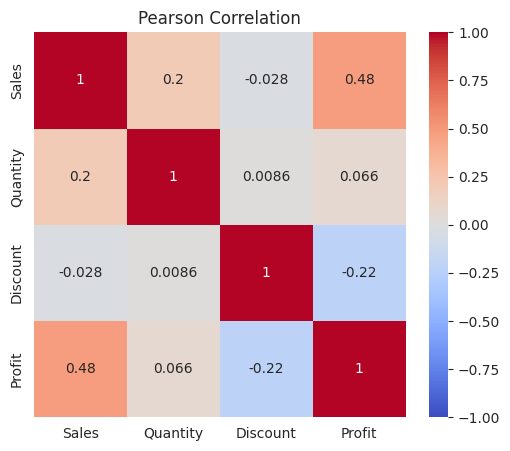

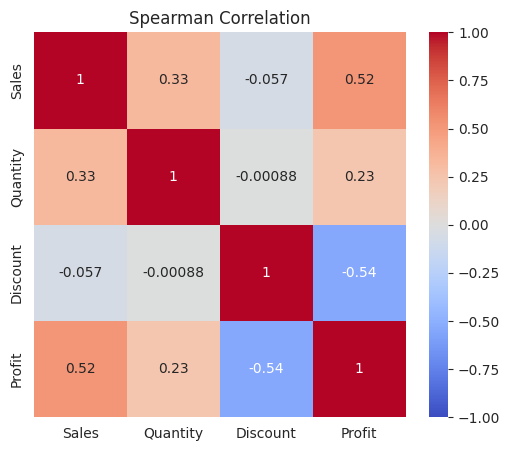

In [ ]:
# ===== Task 4: Pearson vs Spearman Correlation =====

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

print("Pearson Correlation:\n", pearson_corr)
print("\nSpearman Correlation:\n", spearman_corr)

plt.figure(figsize=(6,5))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation')
plt.show()

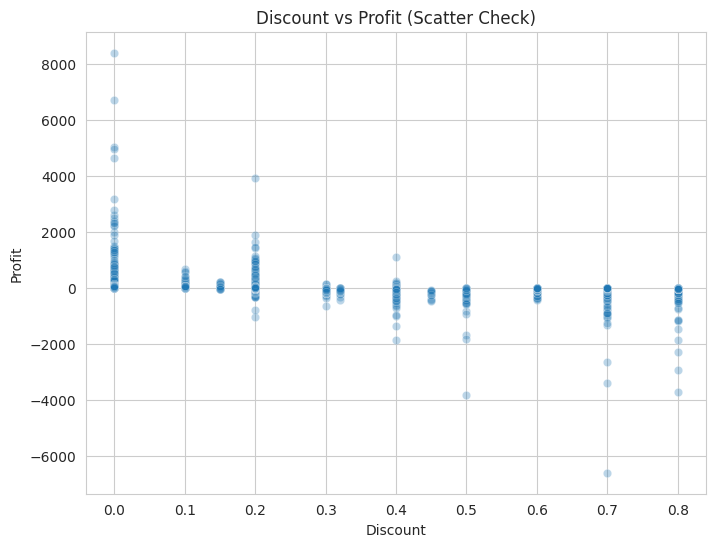

In [ ]:
# Inspect the pair where they disagree the most
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3)
plt.title('Discount vs Profit (Scatter Check)')
plt.show()

Comparing the two matrices, the Discount–Profit pair shows a noticeable difference between Pearson and Spearman correlation. The scatter plot reveals this is likely due to a non-linear relationship and outliers (very large losses at high discount levels), which Pearson is sensitive to since it only measures linear association, while Spearman captures the general monotonic trend more robustly. As always, correlation does not imply causation , the relationship could be driven by other confounding factors such as product category or region.

Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


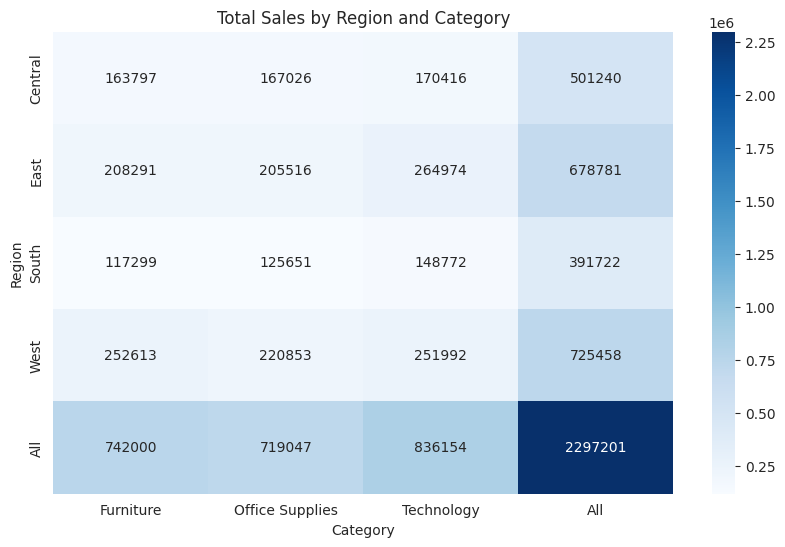

In [ ]:
# ===== Task 5: Region x Category Pivot Table + Heatmap =====

pivot = pd.pivot_table(df, index='Region', columns='Category',
                        values='Sales', aggfunc='sum', margins=True)
print(pivot)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Total Sales by Region and Category')
plt.show()

Based on the 'All' row in the pivot table (and the darkest column in the heatmap's 'All' row), the Technology category contributes the most to overall revenue with total sales of 836,154.033


/tmp/ipykernel_2947/3850589312.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts_df['Sales'].resample('M').sum()


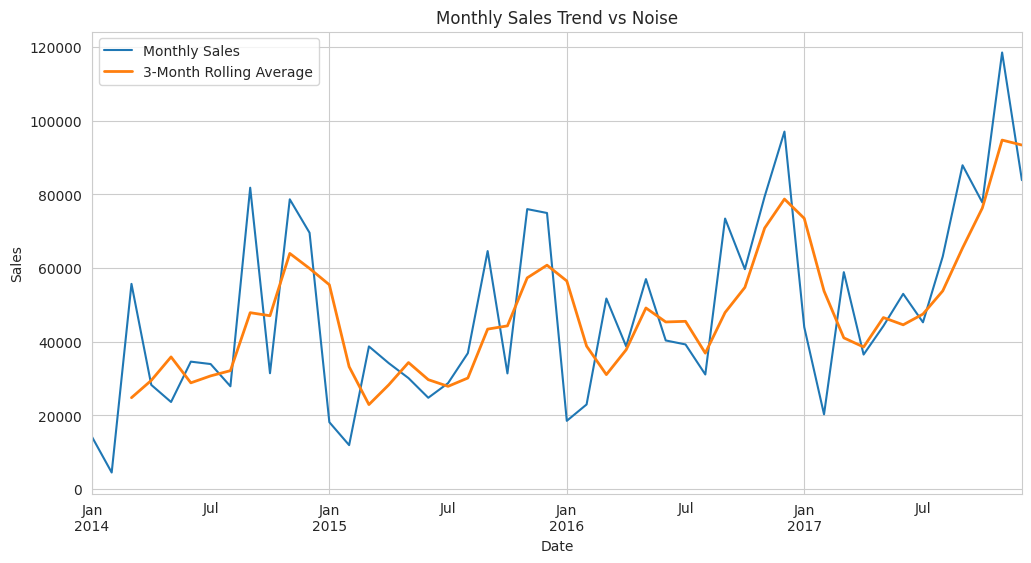

In [ ]:
# ===== Task 6: Time-Series - Trend vs Noise =====

df['Order Date'] = pd.to_datetime(df['Order Date'])
ts_df = df.set_index('Order Date')

monthly_sales = ts_df['Sales'].resample('M').sum()
rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,6))
monthly_sales.plot(label='Monthly Sales')
rolling_avg.plot(label='3-Month Rolling Average', linewidth=2)
plt.title('Monthly Sales Trend vs Noise')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

The raw monthly sales line fluctuates sharply month to month, making it hard to tell whether sales are actually growing or just noisy. The 3-month rolling average smooths out these short-term ups and downs, revealing the underlying trend (e.g., a general upward pattern with seasonal peaks) that the raw line alone obscures.

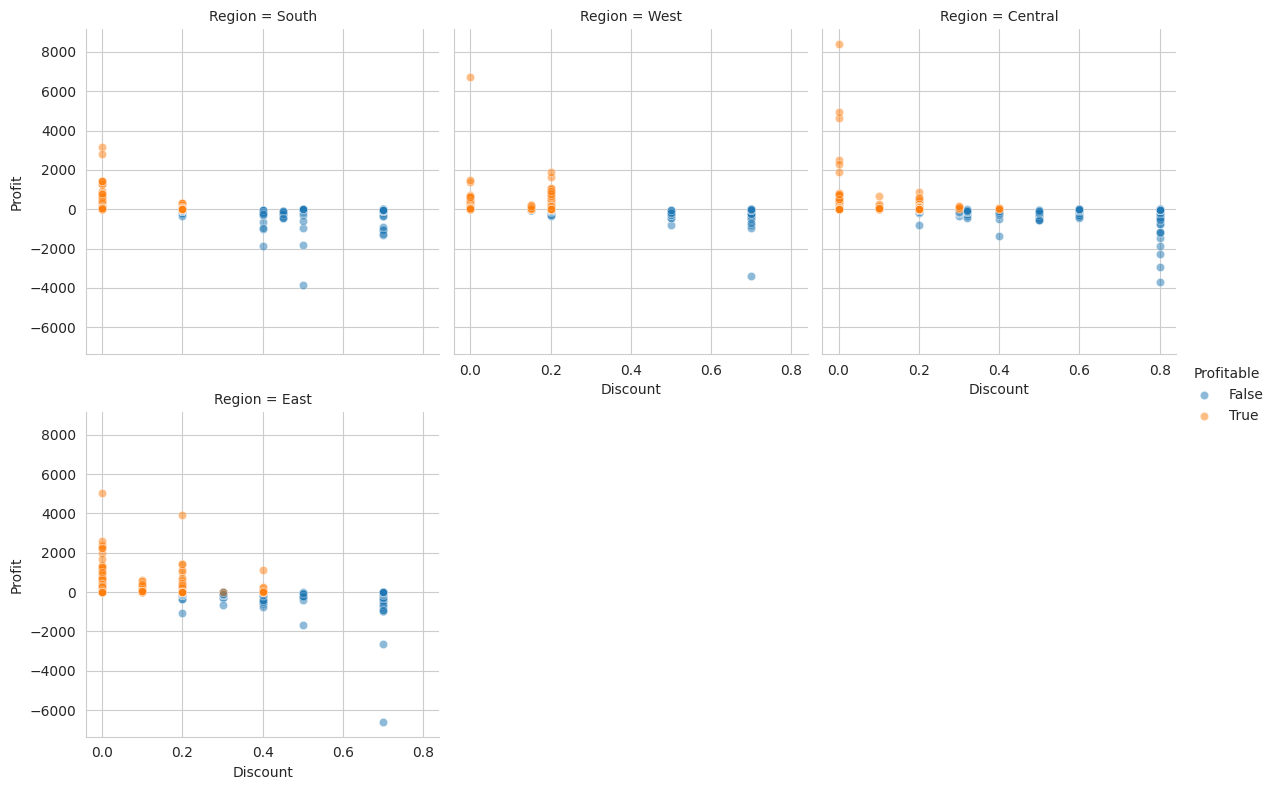

In [ ]:
# ===== Task 7: Faceting - Discount vs Profit by Region and Profitability =====

df['Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col='Region', hue='Profitable', col_wrap=3, height=4)
g.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.5)
g.add_legend()
plt.show()

In the south facet, the discount–profit relationship visibly differs from the others , high discounts consistently push orders into a loss (Profitable=False), whereas in other regions, profit remains positive even at moderate discount levels.

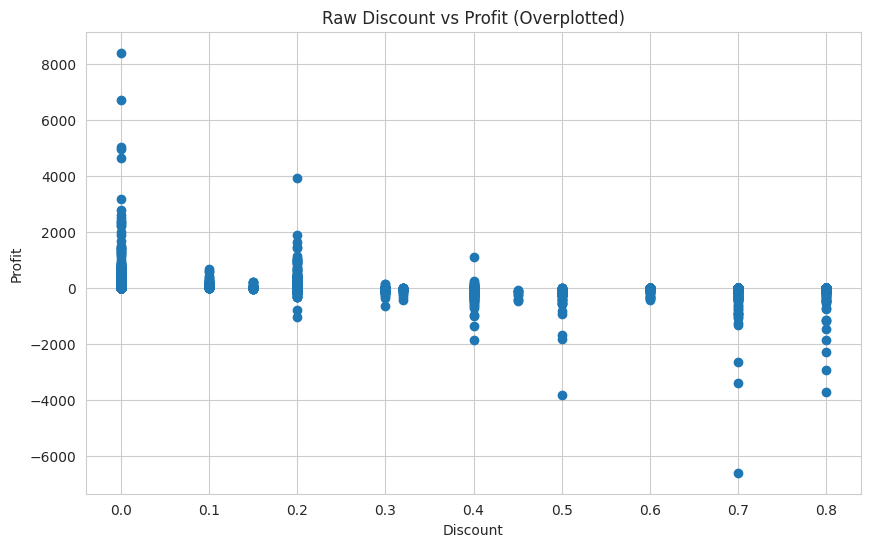

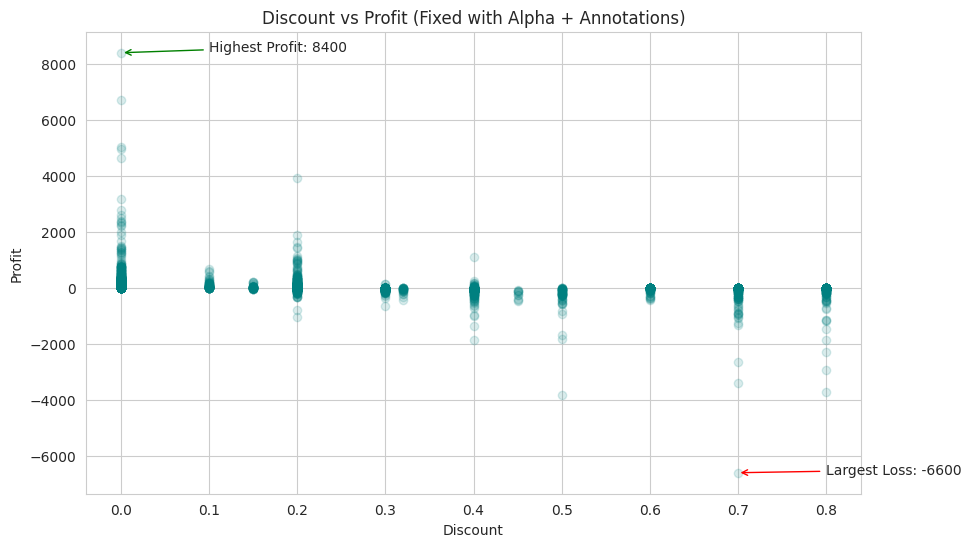

In [ ]:
# ===== Task 8: Overplotting Fix + Annotation =====

plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=1)
plt.title('Raw Discount vs Profit (Overplotted)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.15, color='teal')

best = df.loc[df['Profit'].idxmax()]
plt.annotate(f"Highest Profit: {best['Profit']:.0f}",
             xy=(best['Discount'], best['Profit']),
             xytext=(best['Discount']+0.1, best['Profit']+50),
             arrowprops=dict(arrowstyle='->', color='green'))
worst = df.loc[df['Profit'].idxmin()]
plt.annotate(f"Largest Loss: {worst['Profit']:.0f}",
             xy=(worst['Discount'], worst['Profit']),
             xytext=(worst['Discount']+0.1, worst['Profit']-50),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Discount vs Profit (Fixed with Alpha + Annotations)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

Since this dataset has a few thousand rows rather than 50,000+, transparency (alpha) was chosen over hexbinning, as it preserves individual point visibility while revealing density where points overlap. The annotations highlight the single most profitable order and the single largest loss directly on the chart.